<a href="https://sigmoidal.ai">
  <img src="https://raw.githubusercontent.com/carlosfab/blog-sigmoidal/main/_assets/logo_sigmoidal.png" alt="Sigmoidal" width="300">
</a>

# Gaussian Splatting: Gerando Modelos 3D a Partir de Imagens

**Autor:** Carlos Melo — [sigmoidal.ai](https://sigmoidal.ai)

Neste notebook, vamos gerar um modelo 3D completo a partir de uma unica imagem 2D usando **Gaussian Splatting**.

Para isso, vamos usar o **LGM (Large Gaussian Model)**, que combina dois modelos:
1. **Multi-view Diffusion**: Gera 4 vistas do objeto a partir de uma unica foto
2. **Large Gaussian Model**: Converte as 4 vistas em um modelo Gaussian Splatting

## Setup

Precisamos instalar as dependencias do LGM. O rasterizador de gaussianas vem como um wheel pre-compilado.

In [ ]:
!pip install -q diffusers accelerate transformers xformers kiui plyfile

# Compilar diff_gaussian_rasterization do source
!pip install -q git+https://github.com/ashawkey/diff-gaussian-rasterization.git

  Preparing metadata (setup.py) ... done


In [ ]:
import torch
print(f"CUDA disponivel: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memoria: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

CUDA disponivel: True
GPU: Tesla T4
Memoria: 15.6 GB


## Carregando os Modelos

Vamos carregar os dois modelos do pipeline. Isso pode levar alguns minutos na primeira vez (download dos pesos).

In [ ]:
from diffusers import DiffusionPipeline

# Modelo 1: Multi-view diffusion
# Gera 4 vistas do objeto a partir de 1 imagem
image_pipeline = DiffusionPipeline.from_pretrained(
    "dylanebert/multi-view-diffusion",
    custom_pipeline="dylanebert/multi-view-diffusion",
    torch_dtype=torch.float16,
).to("cuda")

print("Multi-view diffusion carregado.")

Keyword arguments {'trust_remote_code': True} are not expected by MVDreamPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/519 [00:00<?, ?it/s]

Expected types for unet: (<class 'diffusers_modules.local.dylanebert--multi-view-diffusion.3916e5568b2ee54ea8a81ce4961609158b2c464d.pipeline.MultiViewUNetModel'>,), got <class 'diffusers_modules.local.mv_unet.MultiViewUNetModel'>.


Multi-view diffusion carregado.


In [ ]:
# Modelo 2: Large Gaussian Model
# Converte as 4 vistas em gaussianas 3D
splat_pipeline = DiffusionPipeline.from_pretrained(
    "dylanebert/LGM",
    custom_pipeline="dylanebert/LGM",
    torch_dtype=torch.float16,
).to("cuda")

print("LGM carregado.")

Keyword arguments {'trust_remote_code': True} are not expected by LGMPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/1 [00:00<?, ?it/s]

/root/.cache/huggingface/modules/diffusers_modules/local/lgm.py:334: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")


LGM carregado.


## Carregando uma Imagem de Entrada

Vamos usar uma imagem de exemplo. Voce pode trocar por qualquer imagem de um objeto com fundo limpo.

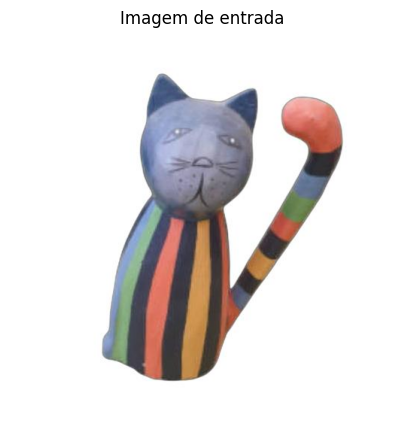

In [ ]:
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

image_url = "https://huggingface.co/datasets/dylanebert/3d-arena/resolve/main/inputs/images/a_cat_statue.jpg"
response = requests.get(image_url)
image = Image.open(BytesIO(response.content))

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis('off')
plt.title('Imagem de entrada')
plt.show()

## Passo 1: Gerando Multi-Views

O modelo de difusao vai imaginar como o objeto se parece visto de 4 angulos diferentes (frente, lado, costas, outro lado). Isso e feito com multi-view diffusion, uma extensao dos modelos de difusao que geram imagens.

In [ ]:
import numpy as np

input_image = np.array(image, dtype=np.float32) / 255.0

multi_view_images = image_pipeline(
    "",
    input_image,
    guidance_scale=5,
    num_inference_steps=30,
    elevation=0
)

print(f"Geradas {len(multi_view_images)} vistas")
print(f"Shape de cada vista: {multi_view_images[0].shape}")

  0%|          | 0/30 [00:00<?, ?it/s]

Geradas 5 vistas
Shape de cada vista: (256, 256, 3)


O modelo retorna 5 imagens: a imagem de entrada reconstruida + 4 vistas novas (frente, direita, costas, esquerda). Vamos visualizar apenas as 4 vistas geradas.

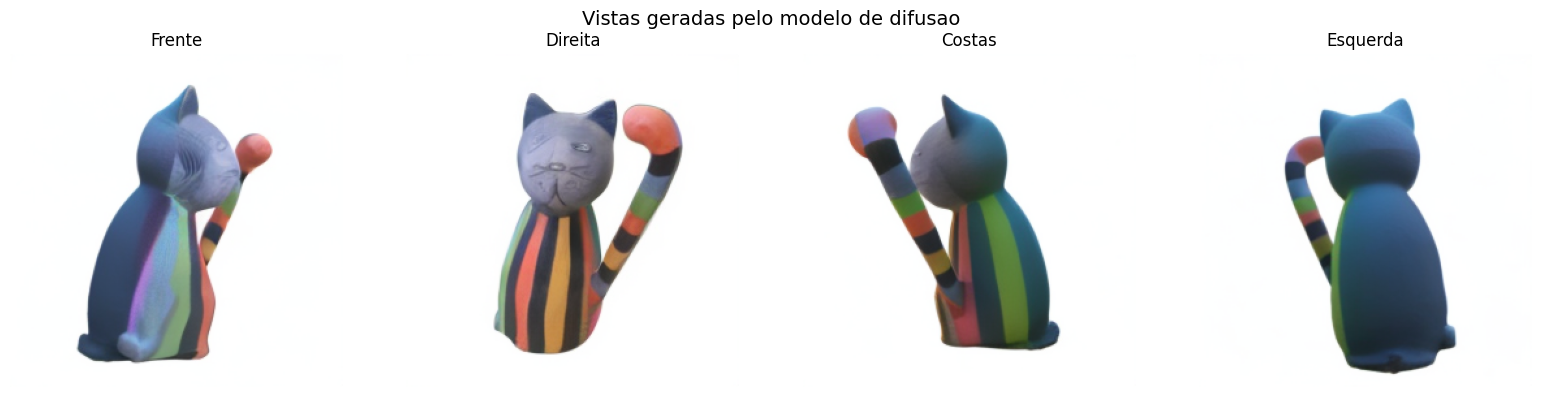

In [ ]:
# Visualizar as 4 vistas geradas
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
labels = ['Frente', 'Direita', 'Costas', 'Esquerda']

for i, (img, label) in enumerate(zip(multi_view_images, labels)):
    axes[i].imshow(img)
    axes[i].set_title(label)
    axes[i].axis('off')

plt.suptitle('Vistas geradas pelo modelo de difusao', fontsize=14)
plt.tight_layout()
plt.show()

A partir de uma unica foto, o modelo de difusao "inventou" como o objeto se parece visto de outros angulos. Isso nao e perfeito, mas e suficiente para gerar um modelo 3D convincente.

## Passo 2: Gerando o Modelo 3D

Agora o LGM pega as 4 vistas e gera um conjunto de gaussianas 3D.

In [ ]:
splat = splat_pipeline(multi_view_images)
print(f"Modelo 3D gerado!")
print(f"Tipo: {type(splat)}")
print(f"Shape: {splat.shape}")

Modelo 3D gerado!
Tipo: <class 'torch.Tensor'>
Shape: torch.Size([1, 65536, 14])


## Salvando o Modelo

Vamos salvar como arquivo `.ply` que pode ser visualizado em qualquer viewer de Gaussian Splatting.

In [ ]:
output_path = "cat_statue.ply"
splat_pipeline.save_ply(splat, output_path)

import os
size_mb = os.path.getsize(output_path) / (1024 * 1024)
print(f"Modelo salvo: {output_path}")
print(f"Tamanho: {size_mb:.1f} MB")

Modelo salvo: cat_statue.ply
Tamanho: 2.2 MB


## Inspecionando o Modelo Gerado

Vamos abrir o `.ply` gerado e olhar as gaussianas, assim como fizemos no Notebook 1.

In [ ]:
from plyfile import PlyData

plydata = PlyData.read(output_path)
vertex = plydata['vertex']

print(f"Numero de gaussianas geradas: {len(vertex):,}")
print(f"Propriedades: {[p.name for p in vertex.properties]}")

Numero de gaussianas geradas: 40,283
Propriedades: ['x', 'y', 'z', 'f_dc_0', 'f_dc_1', 'f_dc_2', 'opacity', 'scale_0', 'scale_1', 'scale_2', 'rot_0', 'rot_1', 'rot_2', 'rot_3']


O modelo gera internamente 65.536 gaussianas (tensor de shape `(1, 65536, 14)`), mas ao salvar o `.ply`, gaussianas com opacidade muito baixa sao removidas. Por isso o arquivo final contem ~40 mil gaussianas uteis.

In [ ]:
import plotly.graph_objects as go

xyz = np.stack([vertex['x'], vertex['y'], vertex['z']], axis=1)

# Tentar extrair cor (depende do formato de saida do LGM)
prop_names = [p.name for p in vertex.properties]

if 'red' in prop_names:
    r = np.array(vertex['red']) / 255.0
    g = np.array(vertex['green']) / 255.0
    b = np.array(vertex['blue']) / 255.0
elif 'f_dc_0' in prop_names:
    C0 = 0.28209479177387814
    r = np.clip(0.5 + C0 * np.array(vertex['f_dc_0']), 0, 1)
    g = np.clip(0.5 + C0 * np.array(vertex['f_dc_1']), 0, 1)
    b = np.clip(0.5 + C0 * np.array(vertex['f_dc_2']), 0, 1)
else:
    r = g = b = np.ones(len(vertex)) * 0.5

colors = [
    f'rgb({int(ri*255)},{int(gi*255)},{int(bi*255)})'
    for ri, gi, bi in zip(r, g, b)
]

In [ ]:
fig = go.Figure(data=[go.Scatter3d(
    x=xyz[:, 0],
    y=xyz[:, 1],
    z=xyz[:, 2],
    mode='markers',
    marker=dict(size=1.5, color=colors, opacity=0.6)
)])
fig.update_layout(
    title='Modelo 3D gerado a partir de uma unica foto',
    width=800, height=600,
    scene=dict(aspectmode='data', bgcolor='black'),
    paper_bgcolor='black'
)
fig.show()

## Visualizando no Browser

A visualizacao com plotly mostra os centros das gaussianas, mas nao as renderiza como elipsoides sobrepostas (que e o que produz o resultado fotorrealista).

Para ver o resultado real, baixe o arquivo `.ply` e arraste para o viewer web:

**[https://antimatter15.com/splat/](https://antimatter15.com/splat/)**

Ou use o SuperSplat para visualizar e editar:

**[https://superspl.at/](https://superspl.at/)**

In [ ]:
# Download do arquivo (Colab)
try:
    from google.colab import files
    files.download(output_path)
    print("Download iniciado. Arraste o arquivo para antimatter15.com/splat/")
except ImportError:
    print(f"Arquivo salvo em: {output_path}")
    print("Abra antimatter15.com/splat/ e arraste o arquivo para la.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download iniciado. Arraste o arquivo para antimatter15.com/splat/


## Testando com Outra Imagem

Vamos testar com uma imagem diferente para ver a versatilidade do modelo.

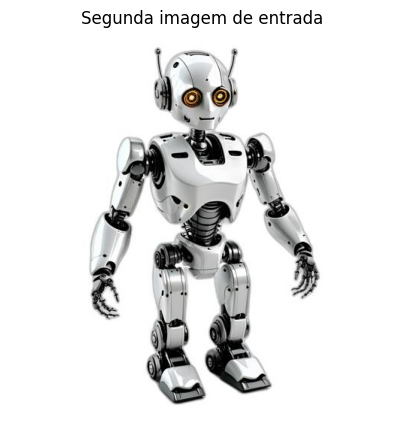

In [ ]:
# Voce pode trocar por qualquer URL de imagem
image_url_2 = "https://huggingface.co/datasets/dylanebert/3d-arena/resolve/main/inputs/images/a_robot.jpg"

response2 = requests.get(image_url_2)
image2 = Image.open(BytesIO(response2.content))

plt.figure(figsize=(5, 5))
plt.imshow(image2)
plt.axis('off')
plt.title('Segunda imagem de entrada')
plt.show()

In [ ]:
input_image2 = np.array(image2, dtype=np.float32) / 255.0

# Pipeline completo: imagem -> multi-views -> gaussianas 3D
multi_views_2 = image_pipeline(
    "", input_image2,
    guidance_scale=5,
    num_inference_steps=30,
    elevation=0
)
splat_2 = splat_pipeline(multi_views_2)

output_path_2 = "robot.ply"
splat_pipeline.save_ply(splat_2, output_path_2)
print(f"Segundo modelo salvo: {output_path_2}")

  0%|          | 0/30 [00:00<?, ?it/s]

Segundo modelo salvo: robot.ply


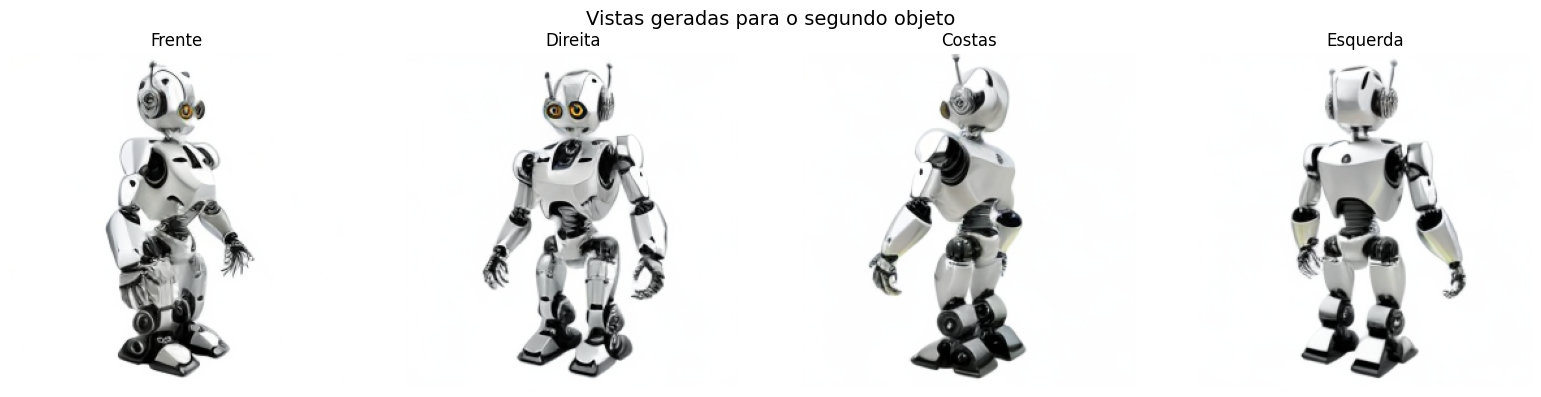

In [ ]:
# Visualizar as multi-views do segundo objeto
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
labels = ['Frente', 'Direita', 'Costas', 'Esquerda']

for i, (img, label) in enumerate(zip(multi_views_2, labels)):
    axes[i].imshow(img)
    axes[i].set_title(label)
    axes[i].axis('off')

plt.suptitle('Vistas geradas para o segundo objeto', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
try:
    from google.colab import files
    files.download(output_path_2)
except ImportError:
    print(f"Arquivo salvo em: {output_path_2}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Usando Sua Propria Imagem

In [ ]:
# Descomente para fazer upload da sua imagem no Colab

# from google.colab import files
# uploaded = files.upload()
# filename = list(uploaded.keys())[0]
# custom_image = Image.open(filename)
#
# input_custom = np.array(custom_image, dtype=np.float32) / 255.0
# views_custom = image_pipeline("", input_custom, guidance_scale=5, num_inference_steps=30, elevation=0)
# splat_custom = splat_pipeline(views_custom)
# splat_pipeline.save_ply(splat_custom, "custom_object.ply")
# files.download("custom_object.ply")